In [4]:
from IPython.display import display
import ipywidgets as widgets

uploader = widgets.FileUpload(accept='', multiple=True)
display(uploader)

def handle_upload(change):
    for filename, file_info in uploader.value.items():
        print(f'User uploaded file "{filename}" with length {len(file_info["content"])} bytes')

uploader.observe(handle_upload, names='value')


FileUpload(value={}, description='Upload', multiple=True)

In [6]:
# STEP 1: Install required libraries
!pip install -q xgboost
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hrish\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [8]:
import pandas as pd
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [18]:
import pandas as pd

df = pd.read_csv(r'"C:\Users\hrish\Downloads\Dataset\IMDB Dataset.csv"')


OSError: [Errno 22] Invalid argument: '"C:\\Users\\hrish\\Downloads\\Dataset\\IMDB Dataset.csv"'

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # Remove HTML
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text

# Apply cleaning
df['cleaned_review'] = df['review'].apply(clean_text)

# Remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])

df['cleaned_review'] = df['cleaned_review'].apply(remove_stopwords)

# Optional: Apply stemming
stemmer = PorterStemmer()

def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

df['cleaned_review'] = df['cleaned_review'].apply(stem_text)

# Encode sentiment labels (positive -> 1, negative -> 0)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])

# Train-test split
X = df['cleaned_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Preprocessing complete. You're ready for TF-IDF vectorization and model training!")

✅ Preprocessing complete. You're ready for TF-IDF vectorization and model training!


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer

# Create a TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=5000)  # You can adjust max_features

# Fit and transform the training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform the test data using the same vectorizer
X_test_tfidf = vectorizer.transform(X_test)

# Initialize and train the Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test_tfidf)
y_probs_rf = rf_model.predict_proba(X_test_tfidf)[:, 1]  # For ROC/PR curves later

print("✅ Random Forest model trained and predictions made.")

✅ Random Forest model trained and predictions made.


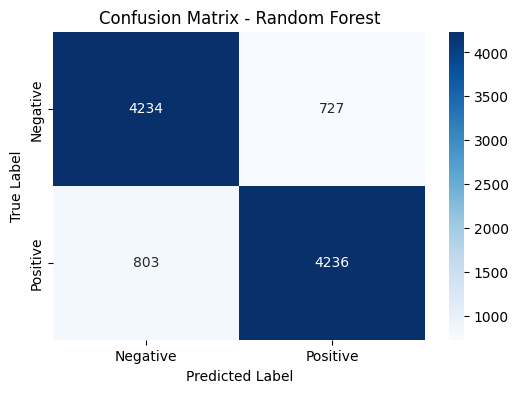

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


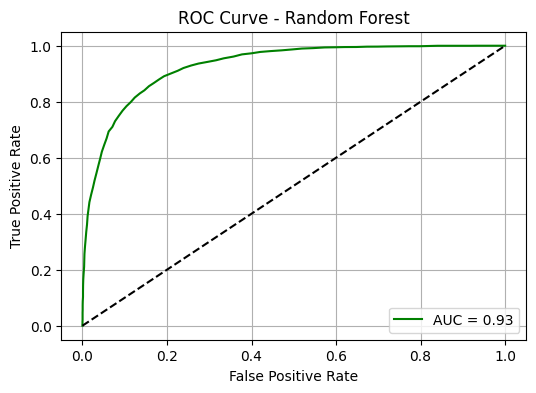

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_probs_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


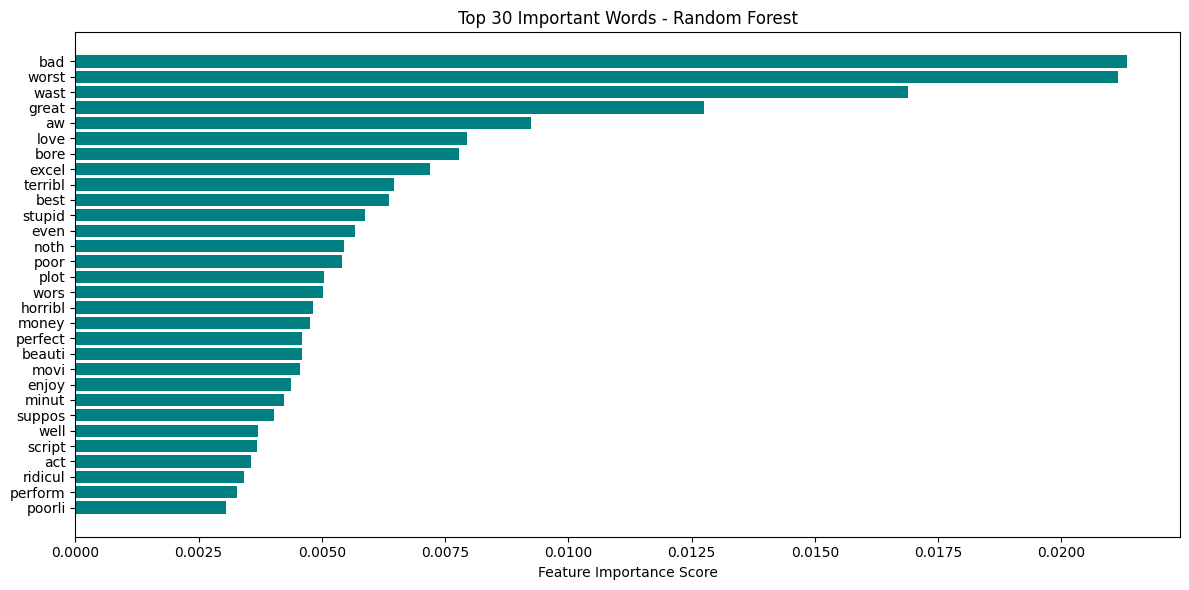

In [ ]:
import numpy as np

# Use 'vectorizer' instead of 'tfidf' to get feature names
feature_names = vectorizer.get_feature_names_out()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-30:]  # Top 30 features

plt.figure(figsize=(12,6))
plt.barh(range(len(indices)), importances[indices], align='center', color='teal')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance Score')
plt.title('Top 30 Important Words - Random Forest')
plt.tight_layout()
plt.show()

In [ ]:
!pip install shap
